In [1]:
import os
import sys
from glob import glob
import warnings

sys.path.insert(1, os.path.abspath(".."))
from pairs_python.core import pairs_quadtree as pqt

import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb
import pyproj
import contextily
#import sqlite3
#import pysqlite3 as sqlite3

import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import vectorstore
"""
from importlib import reload 
reload(vectorstore)
"""

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter, NullFormatter

In [2]:
%%time
# See what tables are present in the sqlite database
def get_sqlite_tables(sqlite_path):
    con = spatialite.connect(sqlite_path)
    cur = con.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cur.fetchall()
    cur.close()
    con.close()
    return tables

sqlite_path = '/data/vector/kaggle_wildfire/FPA_FOD_20170508.sqlite'
tables = get_sqlite_tables(sqlite_path)
#tables

CPU times: user 6.32 ms, sys: 1.44 ms, total: 7.76 ms
Wall time: 5.85 ms


In [3]:
original_dataset = 'kaggle_wildfire'  #'ne_10m_admin_0_countries' 'ne_10m_admin_1_states_provinces' 'ne_10m_admin_2_counties' 
table = 'Fires' #original_dataset #'ne_10m_admin_0_countries'
dataset = 'kaggle_wildfire'
geom_col = 'geometry'  # Needs to be called 'geometry'
temporal_keys = [] #['year']
temporal_partitions = [] #['year']
overview_level = 8 #1 #8 #6
spatial_partition_levels = [4, 6] #[] 
filter_key_levels = [10, 14, 18, 22]

In [4]:
%%time
# Load a table
def load_sqlite_table(sqlite_path, table, limit=None):
    con = spatialite.connect(sqlite_path)    
    #con = sqlite3.connect(sqlite_path)
    con.enable_load_extension(True)
    con.load_extension("mod_spatialite")
    cur = con.cursor()
    # Load the data into a DataFrame
    if limit is not None:
        df_sql = pandas.read_sql_query(f"SELECT * FROM {table} LIMIT {limit}", con)
    else:
        df_sql = pandas.read_sql_query(f"SELECT * FROM {table}", con)
    cur.close()
    con.close()
    return df_sql

limit = None #100 #None
df_sql = load_sqlite_table(sqlite_path, table, limit)
print('df_sql', len(df_sql))
df_sql.tail(2)

df_sql 1880465
CPU times: user 28.5 s, sys: 3.79 s, total: 32.3 s
Wall time: 32.3 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape
1880463,1880464,300348377,2015CAIRS29218079,NONFED,ST-CACDF,ST/C&L,USCATCU,Tuolumne-Calaveras Unit,CATCU,Tuolumne-Calaveras Unit,...,B,37.672235,-120.898356,12.0,MUNICIPAL/LOCAL,CA,None,None,None,b'\x00\x01\xad\x10\x00\x00x\xba_\xaa~9^\xc0\xb...
1880464,1880465,300348399,2015CAIRS26733926,NONFED,ST-CACDF,ST/C&L,USCABDU,San Bernardino Unit,CABDU,CDF - San Bernardino Unit,...,A,34.263217,-116.830950,13.0,STATE OR PRIVATE,CA,None,None,None,b'\x00\x01\xad\x10\x00\x00\x1c\xa7\xe8H.5]\xc0...


In [5]:
# Convert binary geometry to shapely polygon
"""
original_geom_col = 'GEOMETRY'
df_sql[geom_col] = df_sql[original_geom_col].apply(lambda x: wkb.loads(x))
if original_geom_col!=geom_col:
    del df_sql[original_geom_col]
df_sql.tail(2)
"""

"\noriginal_geom_col = 'GEOMETRY'\ndf_sql[geom_col] = df_sql[original_geom_col].apply(lambda x: wkb.loads(x))\nif original_geom_col!=geom_col:\n    del df_sql[original_geom_col]\ndf_sql.tail(2)\n"

In [6]:
%%time
# FIRE_SIZE is in acres. 
# So let's approximate it by buffereing the point to the area of the FIRE_SIZE (ellipse in WGS84)

def get_lat_compression(lon, lat, geod, epsilon=0.0001):
    # Get the dy / dx ratio (in meters) at the point specified
    # geod = pyproj.Geod(ellps='WGS84')
    _, _, x_dist = geod.inv(lon-epsilon, lat, lon+epsilon, lat)
    _, _, y_dist = geod.inv(lon, lat-epsilon, lon, lat+epsilon)
    lat_compression_factor = y_dist / x_dist
    return lat_compression_factor

def buffer_wgs84(lon, lat, fire_size):
    """
    Buffer a point using the correct ellipse in WGS84 coordinates
    """
    geod = pyproj.Geod(ellps='WGS84')

    lat_compression_factor = get_lat_compression(lon, lat, geod)
    fire_area_deg2 = fire_size * 4046.8564224 / 111139 / 111139 * lat_compression_factor
    fire_size_x_deg = numpy.sqrt(fire_area_deg2 / numpy.pi * lat_compression_factor)
    fire_size_y_deg = fire_size_x_deg / lat_compression_factor

    # Circle of radius 1 around center point:
    circ = shapely.geometry.Point(lon, lat).buffer(1)

    # Let create the ellipse along x and y:
    ell  = shapely.affinity.scale(circ, fire_size_x_deg, fire_size_y_deg)
    #ell.area * 111139 * 111139 / lat_compression_factor

    return ell

buffer_wgs84_vec = numpy.vectorize(buffer_wgs84)
df_sql['geometry'] = buffer_wgs84_vec(df_sql['LONGITUDE'], df_sql['LATITUDE'],  df_sql['FIRE_SIZE'])

CPU times: user 8min 42s, sys: 7.2 s, total: 8min 49s
Wall time: 8min 49s


In [7]:
%%time
# Convert to GeoDataFrame
gdf_sql = geopandas.GeoDataFrame(df_sql, geometry=geom_col)
gdf_sql = gdf_sql.set_crs(epsg=4326)
gdf_sql.tail(2)

CPU times: user 10.4 s, sys: 2.6 s, total: 13 s
Wall time: 13 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LATITUDE,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,geometry
1880463,1880464,300348377,2015CAIRS29218079,NONFED,ST-CACDF,ST/C&L,USCATCU,Tuolumne-Calaveras Unit,CATCU,Tuolumne-Calaveras Unit,...,37.672235,-120.898356,12.0,MUNICIPAL/LOCAL,CA,None,None,None,b'\x00\x01\xad\x10\x00\x00x\xba_\xaa~9^\xc0\xb...,"POLYGON ((-120.89778 37.67223, -120.89778 37.6..."
1880464,1880465,300348399,2015CAIRS26733926,NONFED,ST-CACDF,ST/C&L,USCABDU,San Bernardino Unit,CABDU,CDF - San Bernardino Unit,...,34.263217,-116.830950,13.0,STATE OR PRIVATE,CA,None,None,None,b'\x00\x01\xad\x10\x00\x00\x1c\xa7\xe8H.5]\xc0...,"POLYGON ((-116.83083 34.26322, -116.83083 34.2..."


In [8]:
%%time
# Create timestamp column
def dt_from_year_doy(row):
    return (datetime(row[0], 1, 1) + timedelta(int(row[1])-1)).replace(tzinfo=pytz.utc)

dt_col = 'timestamp'
gdf_sql[dt_col] = gdf_sql[['FIRE_YEAR', 'DISCOVERY_DOY']].apply(dt_from_year_doy, axis=1)
gdf_sql = gdf_sql.sort_values(by='timestamp').reset_index(drop=True)
gdf_sql.tail(2)

CPU times: user 25.7 s, sys: 180 ms, total: 25.8 s
Wall time: 25.8 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,geometry,timestamp
1880463,1831008,300251694,SFO-2015TXLFDX594491,NONFED,ST-NASF,ST/C&L,USTXTXS,Texas A & M Forest Service,TXLFDX,Local Fire Department,...,-94.947366,14.0,MISSING/NOT SPECIFIED,TX,Gregg,183,Gregg,b'\x00\x01\xad\x10\x00\x00\x1cv\x95\xa4\xa1\xb...,"POLYGON ((-94.94718 32.43941, -94.94718 32.439...",2015-12-31 00:00:00+00:00
1880464,1801139,300213917,W-688210,FED,DOI-WFMI,BIA,USNMZUA,Zuni Agency,NMZUA,Zuni Agency,...,-108.782890,2.0,BIA,NM,None,None,None,b'\x00\x01\xad\x10\x00\x00`\x97\xa8\xde\x1a2[\...,"POLYGON ((-108.78267 35.08119, -108.78268 35.0...",2015-12-31 00:00:00+00:00


In [9]:
%%time
# Create the Geolab vectorstore
id_col = 'OBJECTID'
intersection_policy = 'original' #'cut' # 'original'
vs = vectorstore.Vectorstore(
    dataset=dataset, temporal_keys=temporal_keys, temporal_partitions=temporal_partitions, 
    overview_level=overview_level, spatial_partition_levels=spatial_partition_levels, filter_key_levels=filter_key_levels,
    dt_col=dt_col, geom_col=geom_col, id_col=id_col, intersection_policy=intersection_policy,
)
vs.load_geodataframe(gdf_sql)
print(*vars(vs).keys(), sep=', ')
vs.gdf_intersection.tail(2)

dataset, vectorstore_directory, dataset_directory, temporal_keys, temporal_partitions, overview_level, spatial_partition_identifier, spatial_partition_levels, partition_order, spatial_partitions, filter_key_levels, intersection_policy, dt_col, geom_col, id_col, overview_level_col, spatial_key_col, overview_key_col, numeric_layers, timestamp_layers, categorical_layers, histogram_for_categorical_layers, percentiles, gdf, total_bounds_polygon, total_bounds_quadtree, total_bounds_cells, gdf_total_bounds_cells, gdf_intersection
CPU times: user 3min 26s, sys: 9.76 s, total: 3min 36s
Wall time: 3min 36s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,timestamp,spatial_key,overview_level,overview_key,partition_level4,partition_level6,filter_key_level10,filter_key_level14,filter_key_level18,filter_key_level22
1880463,1831008,300251694,SFO-2015TXLFDX594491,NONFED,ST-NASF,ST/C&L,USTXTXS,Texas A & M Forest Service,TXLFDX,Local Fire Department,...,2015-12-31 00:00:00+00:00,3784,8,level8_3784,14,236,60550.0,15500933.0,3.968239e+09,NaN
1880464,1801139,300213917,W-688210,FED,DOI-WFMI,BIA,USNMZUA,Zuni Agency,NMZUA,Zuni Agency,...,2015-12-31 00:00:00+00:00,3723,8,level8_3723,14,232,59581.0,15252947.0,NaN,NaN


In [10]:
%%time
# Write the vectorstore to parquet
vs.to_parquet()

CPU times: user 1min 38s, sys: 11.2 s, total: 1min 49s
Wall time: 1min 48s


In [11]:
from importlib import reload 
reload(vectorstore)

<module 'vectorstore' from '/data/mfreitag/software/vector/vectorstore.py'>

In [12]:
vs = vectorstore.Vectorstore(dataset=dataset)
vs.read_vectorstore_settings()
#vars(vs)

In [13]:
# Discover the vectorstore cells of the dataset
vs.metadata_from_parquet()
gdf_meta = vs.gdf_meta
gdf_meta.tail()

,spatial_key,overview_level,geometry,partition_level4,partition_level6,overview_key,filepath
333,9477,8,"POLYGON ((-70.94810 44.21773, -70.94810 46.314...",37,592,level8_9477,/data/vector/vectorstore/kaggle_wildfire/parti...
334,9488,8,"POLYGON ((-68.85094 44.21773, -68.85094 46.314...",37,593,level8_9488,/data/vector/vectorstore/kaggle_wildfire/parti...
335,9489,8,"POLYGON ((-66.75379 44.21773, -66.75379 46.314...",37,593,level8_9489,/data/vector/vectorstore/kaggle_wildfire/parti...
336,9490,8,"POLYGON ((-68.85094 46.31488, -68.85094 48.412...",37,593,level8_9490,/data/vector/vectorstore/kaggle_wildfire/parti...
337,9491,8,"POLYGON ((-66.75379 46.31488, -66.75379 48.412...",37,593,level8_9491,/data/vector/vectorstore/kaggle_wildfire/parti...


In [14]:
%%time
# Calculate and write the overview statistics
numeric_layers = ['FIRE_SIZE', 'DISCOVERY_DOY']
timestamp_layers = ['timestamp']
categorical_layers = ['STATE', 'STAT_CAUSE_DESCR']
histogram_for_categorical_layers = True
percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]
vs.calc_overview_statistics(
    numeric_layers=numeric_layers,
    timestamp_layers=timestamp_layers,
    categorical_layers=categorical_layers,
    histogram_for_categorical_layers=histogram_for_categorical_layers,
    percentiles=percentiles,
)

CPU times: user 19.6 s, sys: 831 ms, total: 20.5 s
Wall time: 18.7 s


In [15]:
from importlib import reload 
reload(vectorstore)

<module 'vectorstore' from '/data/mfreitag/software/vector/vectorstore.py'>

In [16]:
vs = vectorstore.Vectorstore(dataset=dataset)
vs.read_vectorstore_settings()
#vars(vs)

In [17]:
%%time
# Query the layer
#query_polygon = shapely.geometry.box(-123, 39, -121.5, 41)
query_polygon = shapely.geometry.box(-122.5, 40.25, -122.25, 40.50)
#query_polygon = shapely.geometry.box(-180, -90, 180, 90)
#query_polygon = shapely.geometry.box(-120, 30, -90, 50)
query_dt_start = datetime(1980, 1, 1).replace(tzinfo=pytz.utc)
query_dt_end = datetime(2023, 1, 1).replace(tzinfo=pytz.utc)
query_intersection_policy = 'cut' #'original'
"""
query_polygon = None
query_dt_start = None
query_dt_end = None
query_intersection_policy = 'original' #'original'
"""
vs.query_vectorstore(
    query_polygon=query_polygon, query_dt_start=query_dt_start, query_dt_end=query_dt_end, 
    query_intersection_policy=query_intersection_policy, verbose=False
)
gdf_query = vs.gdf_query
gdf_query.tail(2)

CPU times: user 788 ms, sys: 180 ms, total: 968 ms
Wall time: 840 ms


/data/mfreitag/software/python39/lib/python3.9/site-packages/geopandas/array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,spatial_key,overview_level,overview_key,partition_level4,partition_level6,filter_key_level10,filter_key_level14,filter_key_level18,filter_key_level22,geometry
1471,1872143,300308506,SFO-2015CACDFTGU009802,NONFED,ST-NASF,ST/C&L,USCATGU,Tehama-Glenn Unit,CATGU,Tehama-Glenn Unit,...,3053,8,level8_3053,11,190,48849.0,12505555.0,3.201422e+09,NaN,"POLYGON ((-122.41806 40.33317, -122.41806 40.3..."
1472,1871958,300308313,SFO-2015CACDFSHU011527,NONFED,ST-NASF,ST/C&L,USCASHU,Shasta-Trinity Unit,CASHU,Shasta-Trinity Unit,...,3053,8,level8_3053,11,190,48852.0,12506280.0,3.201608e+09,NaN,"POLYGON ((-122.32243 40.48683, -122.32244 40.4..."


<AxesSubplot:>

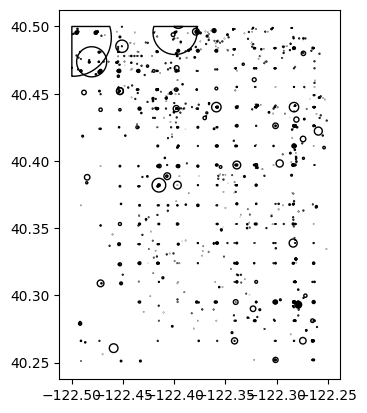

In [18]:
gdf_query.plot(color='None')